In [15]:
import gymnasium as gym
import gymnasium_robotics  # registers FetchReach-v4
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
import base64
from IPython.display import HTML, display
from gymnasium.wrappers import RecordVideo

# Set device (CPU or CUDA)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)


Using device: cpu


In [16]:
# Constants
OBSERVATION_DIM = 10
GOAL_DIM = 3
TOTAL_OBS_DIM = OBSERVATION_DIM + 3 * GOAL_DIM  # 10 + 3 + 3 + 3 = 19
ACTION_DIM = 4
HIDDEN_DIM = 512
GAMMA = 0.95
POLICY_LR = 5e-4
VALUE_LR = 3e-4
ENTROPY_COEF = 0.001
MAX_EPISODES = 50000
MAX_STEPS = 200
PRINT_INTERVAL = 1000
VIDEO_DIR = "./reinforce_videos"

In [17]:
def flatten_observation(obs_dict):
    """
    Concatenate the dictionary observation into a flat vector.
    FetchReach obs dict has keys: 'observation', 'desired_goal', 'achieved_goal'.
    """
    return np.concatenate([
        obs_dict["observation"],
        obs_dict["desired_goal"],
        obs_dict["achieved_goal"],
        obs_dict["desired_goal"] - obs_dict["achieved_goal"],
    ]).astype(np.float32)

def compute_discounted_returns(rewards, gamma=GAMMA):
    """
    Compute discounted returns for a list of rewards.
    R_t = r_t + γ * r_{t+1} + γ² * r_{t+2} + ...
    """
    returns = []
    R = 0.0
    for r in reversed(rewards):
        R = r + gamma * R
        returns.insert(0, R)
    return returns

def embed_mp4_in_notebook(video_path, width=600):
    """Return an HTML video element for a given MP4 file."""
    with open(video_path, "rb") as f:
        video_data = f.read()
    b64 = base64.b64encode(video_data).decode()
    return HTML(f'<video width="{width}" controls><source src="data:video/mp4;base64,{b64}"></video>')

def plot_rewards(rewards, title="REINFORCE with Baseline"):
    """Plot episode rewards and a rolling average."""
    plt.figure(figsize=(10, 5))
    plt.plot(rewards, alpha=0.6, label="Episode Reward")
    if len(rewards) >= 20:
        rolling = np.convolve(rewards, np.ones(20)/20, mode='valid')
        plt.plot(range(19, len(rewards)), rolling, label="20‑Episode Moving Avg", linewidth=2)
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [18]:
class PolicyNetwork(nn.Module):
    """
    Gaussian policy network that outputs a mean and a learnable log‑std.
    """
    def __init__(self, obs_dim, act_dim, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mean_head = nn.Linear(hidden_dim, act_dim)
        self.log_std = nn.Parameter(torch.full((act_dim,), -1.0))  # smaller initial exploration

    def forward(self, x):
        x = self.shared(x)
        mean = self.mean_head(x)
        log_std = self.log_std.clamp(-5, 2)
        std = torch.exp(log_std)
        return mean, std
    def get_action(self, obs_np, deterministic=False):
        """
        Given a flat observation (numpy array), return an action (numpy array).
        """
        obs_t = torch.as_tensor(obs_np, dtype=torch.float32, device=device).unsqueeze(0)
        mean, std = self.forward(obs_t)
        if deterministic:
            action = mean
        else:
            dist = torch.distributions.Normal(mean, std)
            action = dist.sample()
        # Clip to valid action range [-1, 1]
        action = action.clamp(-1.0, 1.0)
        return action.cpu().detach().numpy().squeeze(0)

    def evaluate_actions(self, obs_tensor, actions_tensor):
        """
        Evaluate log probabilities and entropy of given actions under the policy.
        """
        mean, std = self.forward(obs_tensor)
        dist = torch.distributions.Normal(mean, std)
        log_probs = dist.log_prob(actions_tensor).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1)
        return log_probs, entropy

class ValueNetwork(nn.Module):
    """
    Baseline network V(s) that predicts the state value.
    """
    def __init__(self, obs_dim, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

In [19]:
import numpy as np
import gymnasium as gym

class DenseRewardWrapper(gym.Wrapper):
    """
    Dense reward wrapper based on final distance and end-effector stop condition.

    An episode terminates early only when the end-effector is within threshold
    and its speed is below velocity_threshold. Success bonus scales with remaining time.
    """
    def __init__(self, env, base_scale=3.0, success_bonus=50.0, threshold=0.05, velocity_threshold=1e-3):
        super().__init__(env)
        self.base_scale = base_scale
        self.success_bonus = success_bonus
        self.threshold = threshold
        self.velocity_threshold = velocity_threshold

        spec = getattr(env, "spec", None)
        max_steps_from_spec = getattr(spec, "max_episode_steps", None) if spec is not None else None
        self.max_episode_steps = getattr(env, "_max_episode_steps", max_steps_from_spec)

    def step(self, action):
        obs, _, terminated, truncated, info = self.env.step(action)
        achieved = obs["achieved_goal"]
        desired = obs["desired_goal"]
        distance = np.linalg.norm(achieved - desired)

        # FetchReach observation includes end-effector linear velocity in the last 3 entries.
        ee_velocity = obs["observation"][-3:]
        ee_speed = np.linalg.norm(ee_velocity)

        reward = -distance * self.base_scale

        # Success requires both reaching target and coming to a near stop.
        success_and_stopped = (distance < self.threshold) and (ee_speed <= self.velocity_threshold)
        elapsed_steps = getattr(self.env, "_elapsed_steps", None)

        time_bonus = 0.0
        remaining_ratio = 0.0
        if success_and_stopped:
            if (self.max_episode_steps is not None) and (elapsed_steps is not None):
                remaining_steps = max(self.max_episode_steps - elapsed_steps, 0)
                remaining_ratio = remaining_steps / float(self.max_episode_steps)
            
            # Bonus is fully time-based: earlier successful stop => larger bonus.
            time_bonus = self.success_bonus * remaining_ratio
            reward += time_bonus
            terminated = True

        info["distance_to_goal"] = float(distance)
        info["ee_speed"] = float(ee_speed)
        info["stopped_at_target"] = bool(success_and_stopped)
        info["remaining_time_ratio"] = float(remaining_ratio)
        info["time_bonus"] = float(time_bonus)
        return obs, reward, terminated, truncated, info

In [20]:
import time

def train_reinforce_dense_batch(batch_size=5, reward_scale=10.0):
    env = gym.make("FetchReach-v4", render_mode="rgb_array")
    env = DenseRewardWrapper(env, base_scale=3.0, success_bonus=50.0, threshold=0.05)

    policy = PolicyNetwork(TOTAL_OBS_DIM, ACTION_DIM).to(device)
    value_net = ValueNetwork(TOTAL_OBS_DIM).to(device)

    def init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)
    policy.apply(init_weights)
    value_net.apply(init_weights)

    policy_opt = optim.Adam(policy.parameters(), lr=5e-5)
    value_opt = optim.Adam(value_net.parameters(), lr=1e-4)

    policy_scheduler = optim.lr_scheduler.StepLR(policy_opt, step_size=200, gamma=0.95)
    value_scheduler = optim.lr_scheduler.StepLR(value_opt, step_size=200, gamma=0.95)

    episode_rewards = []
    success_history = []
    final_distances = []
    episode_times = []  # Track wall-clock time per episode

    batch_obs = []
    batch_actions = []
    batch_returns = []

    # Setup videos folder
    videos_dir = "./videos"
    if os.path.exists(videos_dir):
        shutil.rmtree(videos_dir)
    os.makedirs(videos_dir, exist_ok=True)

    # Record deterministic policy videos at specific human-readable episode numbers
    video_checkpoints = [1, 10, 100, 1000, 10000, 50000]
    video_episode_map = {ep_num: f"R{ep_num}" for ep_num in video_checkpoints}

    # Training timing
    training_start_time = time.time()
    episode = 0
    while episode < MAX_EPISODES:
        episode_start_time = time.time()
        current_episode_num = episode + 1

        # Check if we need to record a deterministic video for this episode
        should_record = current_episode_num in video_episode_map
        video_name = video_episode_map.get(current_episode_num)

        if should_record:
            # Create environment with video recording
            record_env = gym.make("FetchReach-v4", render_mode="rgb_array")
            record_env = DenseRewardWrapper(record_env, base_scale=1.0, success_bonus=50.0, threshold=0.05)
            record_env = RecordVideo(
                record_env,
                video_folder=videos_dir,
                episode_trigger=lambda x: True,
                name_prefix=video_name
            )
        else:
            record_env = env

        obs_dict, _ = record_env.reset()
        obs = flatten_observation(obs_dict)

        obs_list = []
        actions_list = []
        rewards_list = []

        for step in range(MAX_STEPS):
            action = policy.get_action(obs, deterministic=should_record)
            if np.isnan(action).any():
                print(f"NaN action at episode {current_episode_num}. Resetting environment.")
                obs_dict, _ = record_env.reset()
                obs = flatten_observation(obs_dict)
                obs_list.clear(); actions_list.clear(); rewards_list.clear()
                break

            next_obs_dict, reward, terminated, truncated, _ = record_env.step(action)
            done = terminated or truncated
            next_obs = flatten_observation(next_obs_dict)

            obs_list.append(obs)
            actions_list.append(action)
            rewards_list.append(reward)

            obs = next_obs
            obs_dict = next_obs_dict
            if done:
                break

        # Close recording environment if it was created
        if should_record:
            record_env.close()

        episode_elapsed = time.time() - episode_start_time
        episode_times.append(episode_elapsed)

        if len(rewards_list) < 2:
            continue

        ep_obs = torch.tensor(np.array(obs_list), dtype=torch.float32, device=device)
        ep_actions = torch.tensor(np.array(actions_list), dtype=torch.float32, device=device)

        rewards_array = np.clip(np.array(rewards_list), -10.0 * reward_scale, 10.0 * reward_scale)
        returns = compute_discounted_returns(rewards_array, gamma=GAMMA)
        ep_returns = torch.tensor(returns, dtype=torch.float32, device=device)

        batch_obs.append(ep_obs)
        batch_actions.append(ep_actions)
        batch_returns.append(ep_returns)

        total_reward = sum(rewards_list)
        episode_rewards.append(total_reward)

        final_achieved = obs_dict["achieved_goal"]
        final_desired = obs_dict["desired_goal"]
        final_distance = np.linalg.norm(final_achieved - final_desired)
        final_distances.append(final_distance)
        success = 1 if final_distance < 0.05 else 0
        success_history.append(success)
        episode += 1

        if len(batch_obs) == batch_size:
            all_obs = torch.cat(batch_obs, dim=0)
            all_actions = torch.cat(batch_actions, dim=0)
            all_returns = torch.cat(batch_returns, dim=0)

            returns_mean = all_returns.mean()
            returns_std = all_returns.std() + 1e-8
            all_returns = (all_returns - returns_mean) / returns_std

            values = value_net(all_obs)
            value_loss = nn.MSELoss()(values, all_returns)

            value_opt.zero_grad()
            value_loss.backward()
            torch.nn.utils.clip_grad_norm_(value_net.parameters(), max_norm=0.5)
            value_opt.step()

            with torch.no_grad():
                values_detached = value_net(all_obs)

            advantages = all_returns - values_detached
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

            log_probs, entropy = policy.evaluate_actions(all_obs, all_actions)
            policy_loss = -(log_probs * advantages).mean() - ENTROPY_COEF * entropy.mean()

            policy_opt.zero_grad()
            policy_loss.backward()
            torch.nn.utils.clip_grad_norm_(policy.parameters(), max_norm=0.5)
            policy_opt.step()

            policy_scheduler.step()
            value_scheduler.step()

            batch_obs.clear()
            batch_actions.clear()
            batch_returns.clear()

        if episode % PRINT_INTERVAL == 0 and episode > 0:
            recent_rewards = episode_rewards[-PRINT_INTERVAL:]
            recent_success = success_history[-PRINT_INTERVAL:]
            recent_dist = final_distances[-PRINT_INTERVAL:]
            recent_times = episode_times[-PRINT_INTERVAL:]
            elapsed_total = time.time() - training_start_time
            avg_ep_time = np.mean(recent_times)
            print(f"Episode {episode:5d} | ", end="")
            print(f"Avg Reward: {np.mean(recent_rewards):6.2f} | ", end="")
            print(f"Success Rate: {np.mean(recent_success)*100:5.1f}% | ", end="")
            print(f"Avg Final Dist: {np.mean(recent_dist):.3f} | ", end="")
            print(f"Avg Ep Time: {avg_ep_time:.2f}s | ", end="")
            print(f"Total Time: {elapsed_total/60:.1f}min")

    env.close()
    return policy, value_net, episode_rewards, success_history, final_distances, episode_times

In [21]:
# Run training with batch size = 16 and reward scale = 10.0
policy, value_net, rewards, successes, distances, episode_times = train_reinforce_dense_batch(batch_size=16, reward_scale=10.0)
# 30000 episodes reached 90% success 31.2min

Episode  1000 | Avg Reward: -23.39 | Success Rate:   6.0% | Avg Final Dist: 0.184 | Avg Ep Time: 0.09s | Total Time: 1.6min
Episode  2000 | Avg Reward: -19.53 | Success Rate:   9.2% | Avg Final Dist: 0.150 | Avg Ep Time: 0.08s | Total Time: 3.0min
Episode  3000 | Avg Reward: -18.85 | Success Rate:  10.2% | Avg Final Dist: 0.143 | Avg Ep Time: 0.09s | Total Time: 4.5min
Episode  4000 | Avg Reward: -15.42 | Success Rate:  16.3% | Avg Final Dist: 0.112 | Avg Ep Time: 0.09s | Total Time: 6.0min
Episode  5000 | Avg Reward: -13.69 | Success Rate:  20.2% | Avg Final Dist: 0.100 | Avg Ep Time: 0.09s | Total Time: 7.4min
Episode  6000 | Avg Reward: -11.58 | Success Rate:  26.2% | Avg Final Dist: 0.091 | Avg Ep Time: 0.09s | Total Time: 8.9min
Episode  7000 | Avg Reward:  -9.48 | Success Rate:  29.9% | Avg Final Dist: 0.082 | Avg Ep Time: 0.08s | Total Time: 10.3min
Episode  8000 | Avg Reward:  -7.98 | Success Rate:  37.3% | Avg Final Dist: 0.075 | Avg Ep Time: 0.07s | Total Time: 11.5min
Episod

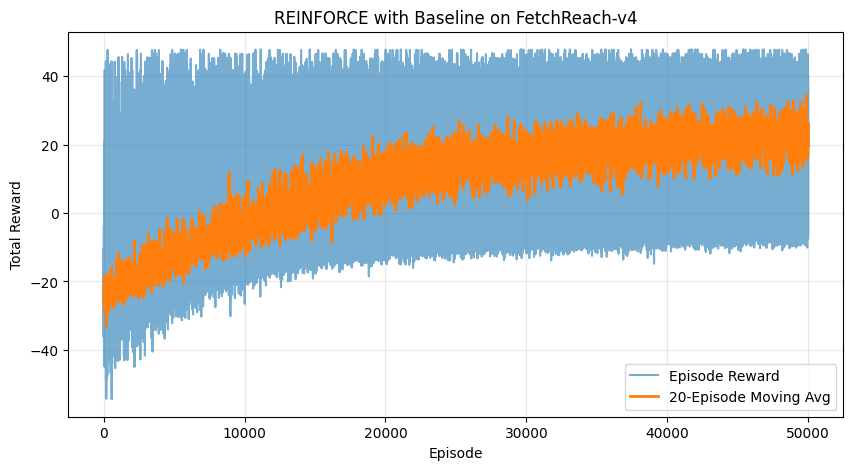

In [22]:
plot_rewards(rewards, title="REINFORCE with Baseline on FetchReach-v4")

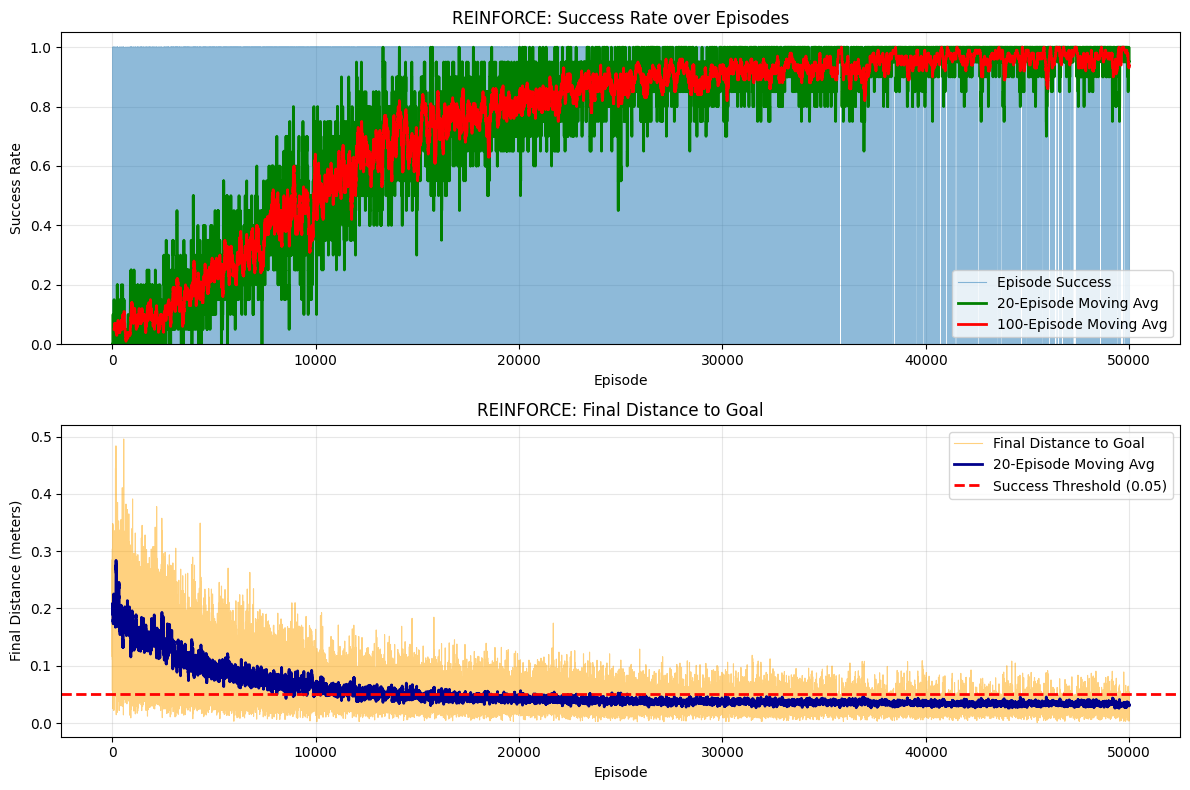

In [23]:
# Plot Success Rate and Final Distances
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Success rate plot
ax1 = axes[0]
ax1.plot(successes, alpha=0.5, label="Episode Success", linewidth=0.8)
if len(successes) >= 20:
    rolling_success = np.convolve(successes, np.ones(20)/20, mode='valid')
    ax1.plot(range(19, len(successes)), rolling_success, label="20-Episode Moving Avg", linewidth=2, color='green')
if len(successes) >= 100:
    rolling_success_100 = np.convolve(successes, np.ones(100)/100, mode='valid')
    ax1.plot(range(99, len(successes)), rolling_success_100, label="100-Episode Moving Avg", linewidth=2, color='red')
ax1.set_xlabel("Episode")
ax1.set_ylabel("Success Rate")
ax1.set_title("REINFORCE: Success Rate over Episodes")
ax1.set_ylim([0, 1.05])
ax1.legend()
ax1.grid(True, alpha=0.3)

# Final distances plot
ax2 = axes[1]
ax2.plot(distances, alpha=0.5, label="Final Distance to Goal", linewidth=0.8, color='orange')
if len(distances) >= 20:
    rolling_dist = np.convolve(distances, np.ones(20)/20, mode='valid')
    ax2.plot(range(19, len(distances)), rolling_dist, label="20-Episode Moving Avg", linewidth=2, color='darkblue')
ax2.axhline(y=0.05, color='r', linestyle='--', linewidth=2, label="Success Threshold (0.05)")
ax2.set_xlabel("Episode")
ax2.set_ylabel("Final Distance (meters)")
ax2.set_title("REINFORCE: Final Distance to Goal")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

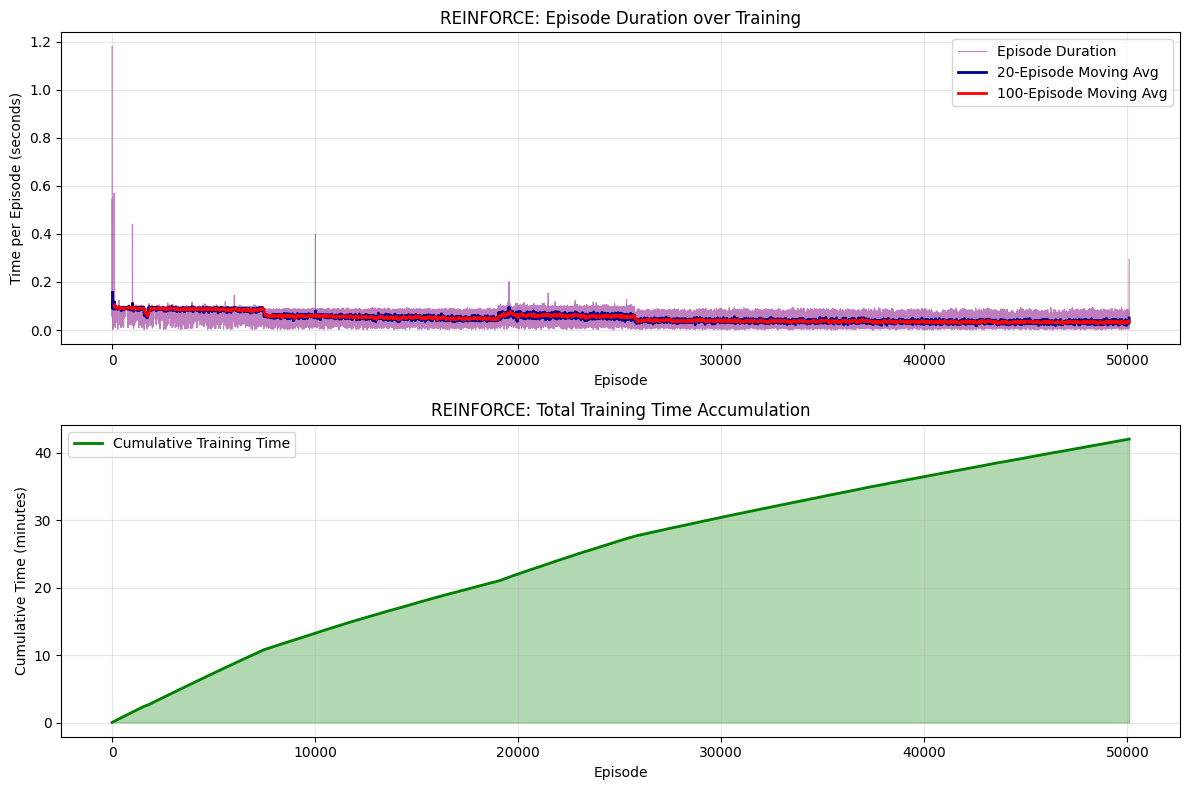


Episode Duration Statistics:
Mean episode time: 0.050s
Median episode time: 0.049s
Min episode time: 0.000s
Max episode time: 1.180s
Total training time: 42.1 minutes (0.7 hours)


In [24]:
# Plot Episode Duration Trends
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Episode time plot
ax1 = axes[0]
ax1.plot(episode_times, alpha=0.5, label="Episode Duration", linewidth=0.8, color='purple')
if len(episode_times) >= 20:
    rolling_time = np.convolve(episode_times, np.ones(20)/20, mode='valid')
    ax1.plot(range(19, len(episode_times)), rolling_time, label="20-Episode Moving Avg", linewidth=2, color='darkblue')
if len(episode_times) >= 100:
    rolling_time_100 = np.convolve(episode_times, np.ones(100)/100, mode='valid')
    ax1.plot(range(99, len(episode_times)), rolling_time_100, label="100-Episode Moving Avg", linewidth=2, color='red')
ax1.set_xlabel("Episode")
ax1.set_ylabel("Time per Episode (seconds)")
ax1.set_title("REINFORCE: Episode Duration over Training")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Cumulative time plot
ax2 = axes[1]
cumulative_time = np.cumsum(episode_times) / 60  # Convert to minutes
ax2.plot(cumulative_time, linewidth=2, color='green', label="Cumulative Training Time")
ax2.fill_between(range(len(cumulative_time)), cumulative_time, alpha=0.3, color='green')
ax2.set_xlabel("Episode")
ax2.set_ylabel("Cumulative Time (minutes)")
ax2.set_title("REINFORCE: Total Training Time Accumulation")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary stats
print(f"\nEpisode Duration Statistics:")
print(f"Mean episode time: {np.mean(episode_times):.3f}s")
print(f"Median episode time: {np.median(episode_times):.3f}s")
print(f"Min episode time: {np.min(episode_times):.3f}s")
print(f"Max episode time: {np.max(episode_times):.3f}s")
print(f"Total training time: {cumulative_time[-1]:.1f} minutes ({cumulative_time[-1]/60:.1f} hours)")

In [25]:
def record_evaluation_video(policy, num_episodes=1, deterministic=True):
    videos_dir = "./videos"

    # Clean previous videos
    if os.path.exists(videos_dir):
        shutil.rmtree(videos_dir)
    os.makedirs(videos_dir, exist_ok=True)

    distances = []
    total_rewards = []

    for ep in range(num_episodes):
        # Create environment with video recording (only for the last episode to avoid overwriting)
        if ep == num_episodes - 1:
            env = gym.make("FetchReach-v4", render_mode="rgb_array")
            env = RecordVideo(
                env,
                video_folder=videos_dir,
                episode_trigger=lambda x: True,
                name_prefix="REINFORCE_eval",
            )
        else:
            env = gym.make("FetchReach-v4", render_mode="rgb_array")

        obs_dict, _ = env.reset()
        obs = flatten_observation(obs_dict)
        done = False
        episode_reward = 0

        while not done:
            action = policy.get_action(obs, deterministic=deterministic)
            obs_dict, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            obs = flatten_observation(obs_dict)
            episode_reward += reward

        final_distance = np.linalg.norm(obs_dict["achieved_goal"] - obs_dict["desired_goal"])
        distances.append(final_distance)
        total_rewards.append(episode_reward)

        env.close()

    avg_distance = np.mean(distances)
    avg_reward = np.mean(total_rewards)
    success_rate = np.mean([d < 0.05 for d in distances]) * 100

    print(f"Evaluation over {num_episodes} episodes:")
    print(f"Avg Final Distance: {avg_distance:.3f}")
    print(f"Avg Total Reward: {avg_reward:.2f}")
    print(f"Success Rate: {success_rate:.1f}%")

    # Find the recorded video (from the last episode)
    video_files = sorted([f for f in os.listdir(videos_dir) if f.endswith(".mp4")])
    if video_files:
        video_path = os.path.join(videos_dir, video_files[-1])
        return embed_mp4_in_notebook(video_path)
    else:
        print("No video recorded.")
        return None

# Record and show video
video_widget = record_evaluation_video(policy, num_episodes=10, deterministic=True)
if video_widget:
    display(video_widget)

Evaluation over 10 episodes:
Avg Final Distance: 0.019
Avg Total Reward: -5.50
Success Rate: 100.0%


In [26]:
# Save
torch.save({
    'policy_state_dict': policy.state_dict(),
    'value_state_dict': value_net.state_dict(),
    'rewards': rewards,
    'successes': successes
}, "reinforce_fetchreach.pt")
print("Model saved.")

# Load (example)
# checkpoint = torch.load("reinforce_fetchreach.pt")
# policy.load_state_dict(checkpoint['policy_state_dict'])
# value_net.load_state_dict(checkpoint['value_state_dict'])

Model saved.


In [27]:
# Save training metrics for cross-notebook comparison
os.makedirs("comparison_logs", exist_ok=True)
np.savez(
    "comparison_logs/reinforce_metrics.npz",
    successes=np.asarray(successes, dtype=np.float32),
    episode_times=np.asarray(episode_times, dtype=np.float32),
)
print("Saved comparison_logs/reinforce_metrics.npz")

Saved comparison_logs/reinforce_metrics.npz


In [28]:
# Save training metrics (v2) including final distances for cross-notebook comparison
os.makedirs("comparison_logs", exist_ok=True)
np.savez(
    "comparison_logs/reinforce_metrics.npz",
    successes=np.asarray(successes, dtype=np.float32),
    episode_times=np.asarray(episode_times, dtype=np.float32),
    final_distances=np.asarray(distances, dtype=np.float32),
)
print("Saved comparison_logs/reinforce_metrics.npz (with final_distances)")

Saved comparison_logs/reinforce_metrics.npz (with final_distances)
